# Trabajo de Laboratorio 4: Filtros digitales y FFT

Instalamos numpy y scipy

In [1]:
pip install numpy scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: C:\Users\herra\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

## Ejercicio 2

In [14]:
fs = 10000
fp = 970

# orden
numtaps = 527

# blackman 765
# hamming 545
# hann 800
# bartlett 10000
# boxcar

# ventanas a probar
windows = [
    'boxcar',    # rectangular
    'bartlett',
    'hann',
    'hamming',
    'blackman'
]

win = "hamming"

Ejemplo de filtro con ventana "Hann"

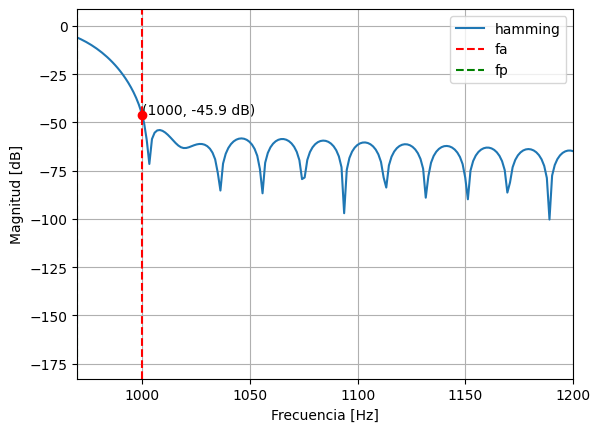

In [15]:
plt.figure()
fs_ds = 2000
fa  = fs_ds / 2

h = signal.firwin(
    numtaps,
    cutoff=fp,
    window=win,
    fs=fs
)


w, H = signal.freqz(h, worN=4096, fs=fs)

H_db = 20*np.log10(np.abs(H) + 1e-12)

plt.plot(w, H_db, label=f"{win}")

y_fa = np.interp(fa, w, H_db)
plt.text(fa, y_fa, f"({fa:.0f}, {y_fa:.1f} dB)")

plt.axvline(fa, linestyle='--', color='red', label='fa')
plt.axvline(fp, linestyle='--', color='green', label='fp')

plt.scatter(fa, y_fa, color='red', zorder=5)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.legend()
plt.xlim(fp, 1.2*fa)
plt.grid()
plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 10000
fp = 970
fa = 1000

windows = ['boxcar', 'bartlett', 'hann', 'hamming', 'blackman']

def cumple_especificacion(numtaps, win):
    h = signal.firwin(numtaps, cutoff=fp, window=win, fs=fs)
    w, H = signal.freqz(h, worN=4096, fs=fs)
    H_db = 20*np.log10(np.abs(H) + 1e-12)
    
    # --- banda de rechazo completa ---
    idx = w >= fa
    H_stop = H_db[idx]
    
    peor_caso = np.max(H_stop)  # peor punto (el más alto en dB)
    
    return peor_caso <= -50, peor_caso

resultados = {}

for win in windows:
    print(f"\nProbando ventana: {win}")
    
    numtaps = 51  # mejor empezar impar
    encontrado = False
    
    while numtaps < 5000:
        ok, peor_caso = cumple_especificacion(numtaps, win)
        
        if ok:
            print(f"✔ Cumple con {numtaps} taps (peor caso ≥1000Hz = {peor_caso:.2f} dB)")
            resultados[win] = numtaps
            encontrado = True
            break
        
        numtaps += 2  # mantener impar
    
    if not encontrado:
        print("❌ No cumple en el rango probado")

print("\nResumen:")
for win, taps in resultados.items():
    print(f"{win}: {taps} taps")


Probando ventana: boxcar
❌ No cumple en el rango probado

Probando ventana: bartlett
❌ No cumple en el rango probado

Probando ventana: hann
✔ Cumple con 761 taps (peor caso ≥1000Hz = -50.10 dB)

Probando ventana: hamming
✔ Cumple con 527 taps (peor caso ≥1000Hz = -50.22 dB)

Probando ventana: blackman
✔ Cumple con 741 taps (peor caso ≥1000Hz = -50.21 dB)

Resumen:
hann: 761 taps
hamming: 527 taps
blackman: 741 taps


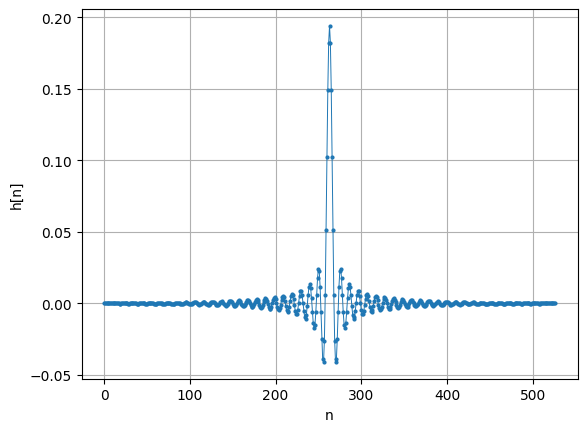

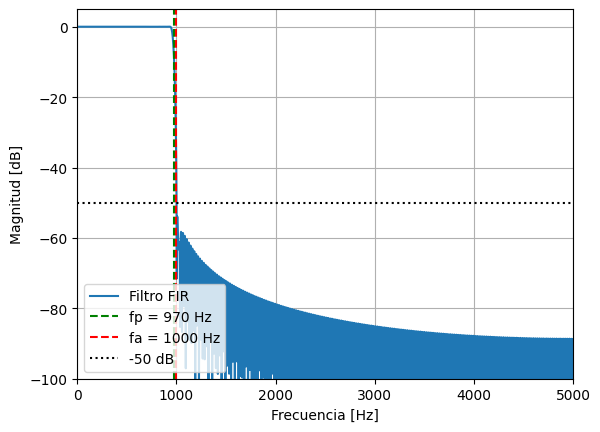

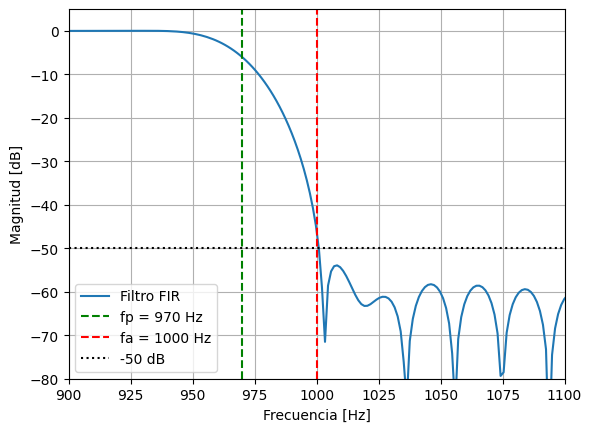

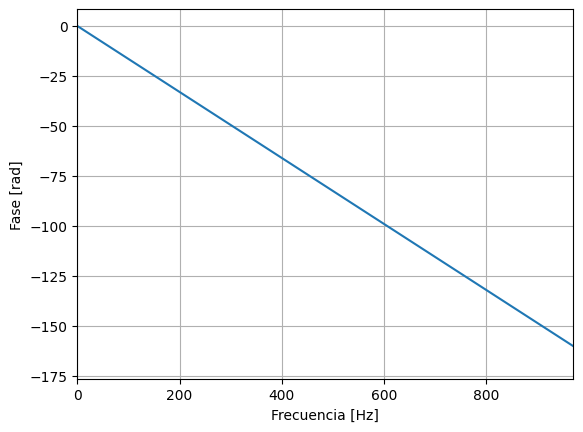

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- parámetros ---
fs = 10000
fp = 970
fa = 1000
numtaps = 527
win = 'hamming'

# --- diseño del filtro ---
h = signal.firwin(numtaps, cutoff=fp, window=win, fs=fs)

# --- respuesta en frecuencia ---
w, H = signal.freqz(h, worN=4096, fs=fs)
H_db = 20*np.log10(np.abs(H) + 1e-12)
H_phase = np.unwrap(np.angle(H))

# --- peor caso en banda de rechazo ---
idx_stop = w >= fa
H_stop = H_db[idx_stop]
w_stop = w[idx_stop]

peor_valor = np.max(H_stop)
peor_freq = w_stop[np.argmax(H_stop)]

# =========================
# 1) RESPUESTA IMPULSIVA
# =========================
plt.figure()
plt.plot(h, marker='o', markersize=2, linewidth=0.7)
plt.xlabel("n")
plt.ylabel("h[n]")
plt.grid()

# =========================
# 2) MAGNITUD COMPLETA
# =========================
plt.figure()
plt.plot(w, H_db, label='Filtro FIR')

plt.axvline(fp, color='green', linestyle='--', label='fp = 970 Hz')
plt.axvline(fa, color='red', linestyle='--', label='fa = 1000 Hz')
plt.axhline(-50, color='black', linestyle=':', label='-50 dB')

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.xlim(0, fs/2)
plt.ylim(-100, 5)
plt.legend(loc='lower left')
plt.grid()

# =========================
# 3) ZOOM TRANSICIÓN
# =========================
plt.figure()
plt.plot(w, H_db, label='Filtro FIR')

plt.axvline(fp, color='green', linestyle='--', label='fp = 970 Hz')
plt.axvline(fa, color='red', linestyle='--', label='fa = 1000 Hz')
plt.axhline(-50, color='black', linestyle=':', label='-50 dB')

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.xlim(900, 1100)
plt.ylim(-80, 5)
plt.legend(loc='lower left')
plt.grid()

# =========================
# 4) FASE
# =========================
plt.figure()
plt.plot(w, H_phase)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [rad]")
plt.xlim(0, fp)
plt.grid()

plt.show()

Señal de entrada de prueba

In [31]:
fs = 10000
f = 600
t = np.arange(0, 10, 1/fs)
x = signal.square(2*np.pi*600*t)

(0.0, 0.06)

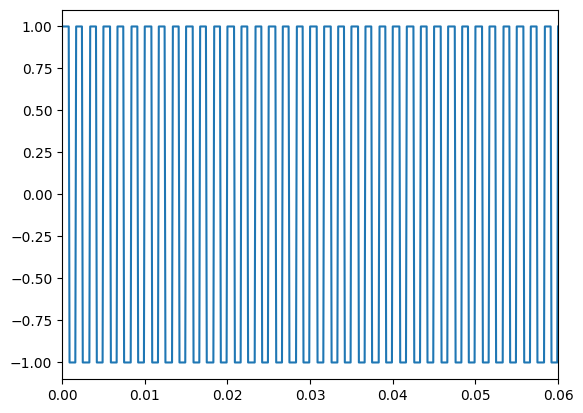

In [30]:
plt.plot(t, x)
plt.xlim(0, 600/fs)

Escriba su función de procesamiento FIR acá

In [ ]:
import numpy as np
import time

def fir_filter(x, h):
    x = np.asarray(x)
    h = np.asarray(h)
    
    N = len(h)
    L = len(x)
    
    y = np.zeros(L)
    
    #Debemos realizar la convolución de h y x
    for n in range(0, len(x)):
        for k in range(0, len(h)):
            if n-k>=0:
                y[n] += h[k] * x[n-k]

    return y

(0.0, 1.0)

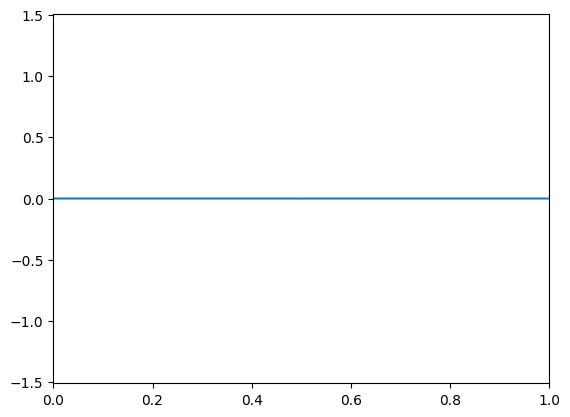

In [ ]:
y = fir_filter(x, h)

plt.plot(y)
plt.xlim(0, 10000/fs)

## Ejercicio 3: FIR aplicando Overlap and Save

In [129]:
import numpy as np
import time

def overlap_save_fir(x, h, L=1024):
    x = np.asarray(x)
    h = np.asarray(h)
    
    N = len(h)
    K =             # tamaño FFT
    
    # Complete su código acá

    return y

SyntaxError: invalid syntax (3511122254.py, line 9)

In [ ]:
# Overlap-Save
y = overlap_save_fir(x, h, L=1024)